# Titanic Exploratory Data Analysis (EDA)

This notebook explores the Titanic dataset through visualizations.

The goals of this notebook are:
- analyze survival distribution
- compare survival across gender and passenger class
- inspect age distribution
- explore relationships between numerical variables

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.load_data import load_data
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = load_data()
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Survival Distribution

This plot shows the overall distribution of passengers who survived versus those who did not survive.

It helps us understand the class balance of the target variable.

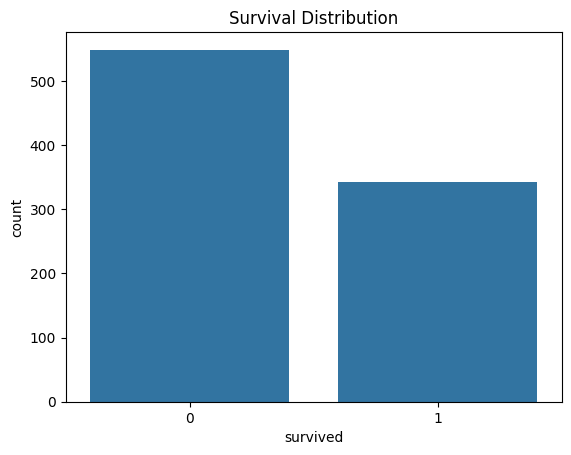

In [4]:
sns.countplot(data=df, x="survived")
plt.title("Survival Distribution")
plt.show()

## Survival by Gender

This plot shows the survival distribution based on passenger gender.

It helps us understand whether gender had a strong influence on survival probability.

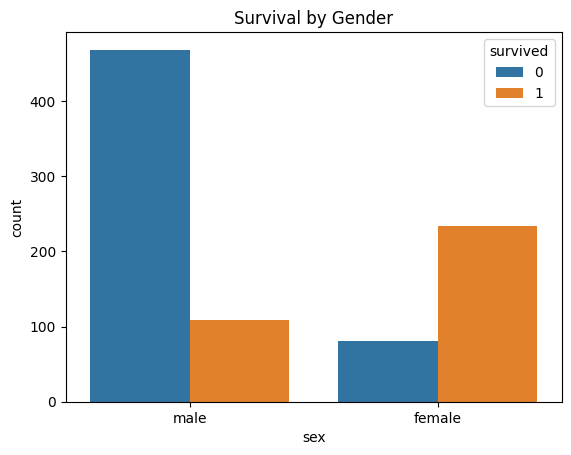

In [5]:
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Survival by Gender")
plt.show()

## Survival by Passenger Class

This plot shows how survival rates varied across passenger classes.

It helps us understand whether socioeconomic status may have influenced survival.

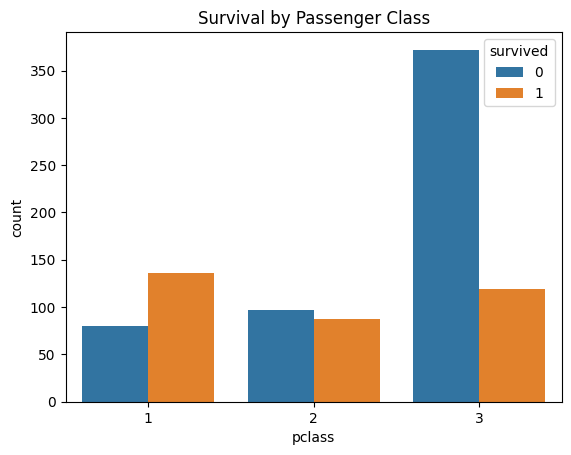

In [6]:
sns.countplot(data=df, x="pclass", hue="survived")
plt.title("Survival by Passenger Class")
plt.show()

## Age Distribution

This histogram shows the distribution of passenger ages.

It helps us identify the most common age ranges in the dataset.

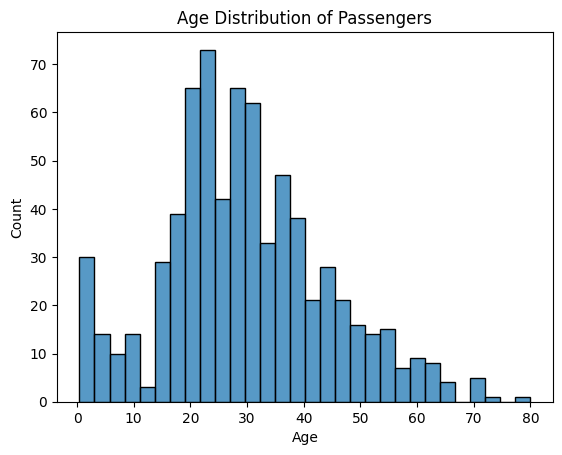

In [7]:
sns.histplot(df["age"], bins=30)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## Age Distribution by Survival

This plot compares the age distribution between survivors and non-survivors.

It helps us explore whether age may have influenced survival.

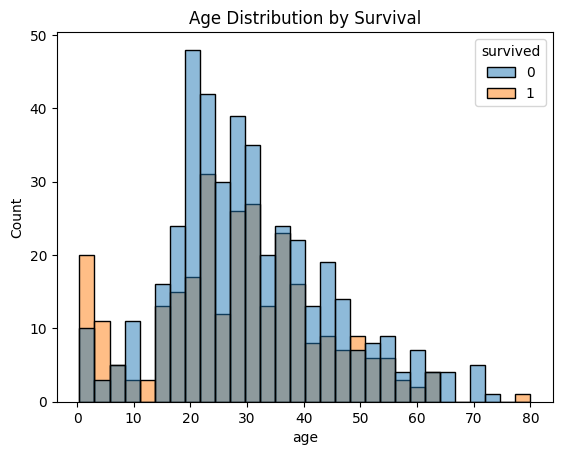

In [9]:
sns.histplot(data=df, x="age", hue="survived", bins=30)
plt.title("Age Distribution by Survival")
plt.show()

## Age vs Survival

This boxplot compares the age distribution of survivors and non-survivors.

It helps us examine whether the two groups differ in age.

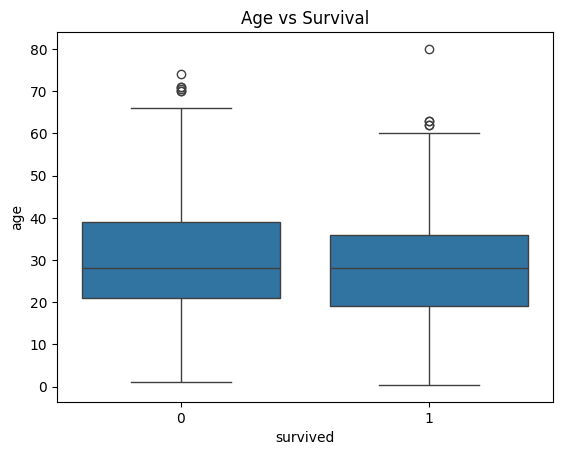

In [10]:
sns.boxplot(data=df, x="survived", y="age")
plt.title("Age vs Survival")
plt.show()

## Correlation Heatmap

This heatmap shows the correlation between numerical variables in the dataset.

It helps us understand which numerical features may be related to survival.

In [11]:
corr = df.corr(numeric_only=True)
corr

,passengerid,survived,pclass,age,sibsp,parch,fare
passengerid,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


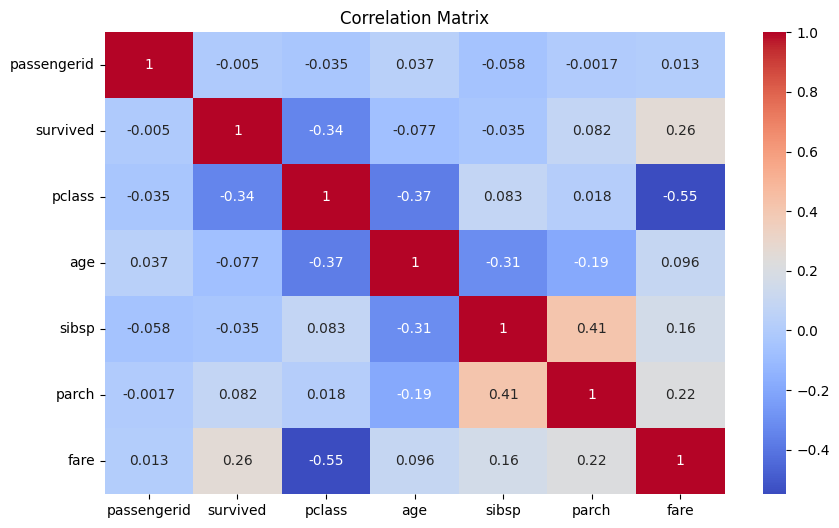

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## EDA Summary

From the visual analysis, we can already observe that:
- survival is not evenly distributed
- gender appears strongly related to survival
- passenger class also seems important
- age may have some influence, especially for children